In [15]:
!pip install xgboost

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor

In [17]:
df = pd.read_csv('/content/StudentsPerformance.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [18]:
# Create Total Score

df['total_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)

# Create Average Score

df['average_score'] = df['total_score'] / 3

In [19]:
def grade(score):

    if score >= 90:
        return 'A'

    elif score >= 75:
        return 'B'

    elif score >= 50:
        return 'C'

    else:
        return 'Fail'


df['grade'] = df['average_score'].apply(grade)

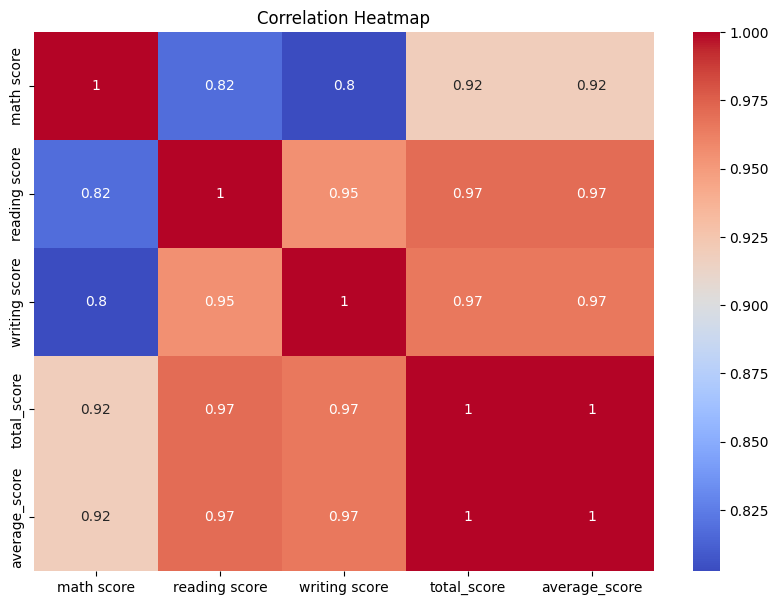

In [20]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

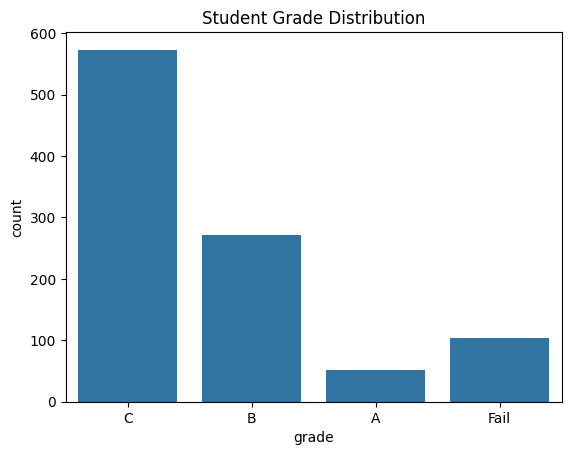

In [21]:
sns.countplot(x='grade', data=df)

plt.title("Student Grade Distribution")

plt.show()

In [22]:
df = pd.get_dummies(df, drop_first=True)

In [23]:
X = df.drop('average_score', axis=1)

y = df['average_score']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(),

    "Random Forest": RandomForestRegressor(),

    "Gradient Boosting": GradientBoostingRegressor(),

    "XGBoost": XGBRegressor()
}

In [26]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    score = r2_score(y_test, prediction)

    results[name] = score

    print(name, ":", score)

Linear Regression : 1.0
Decision Tree : 0.9975720338325416
Random Forest : 0.9965674262100503
Gradient Boosting : 0.9976981779494545
XGBoost : 0.9975282298107699


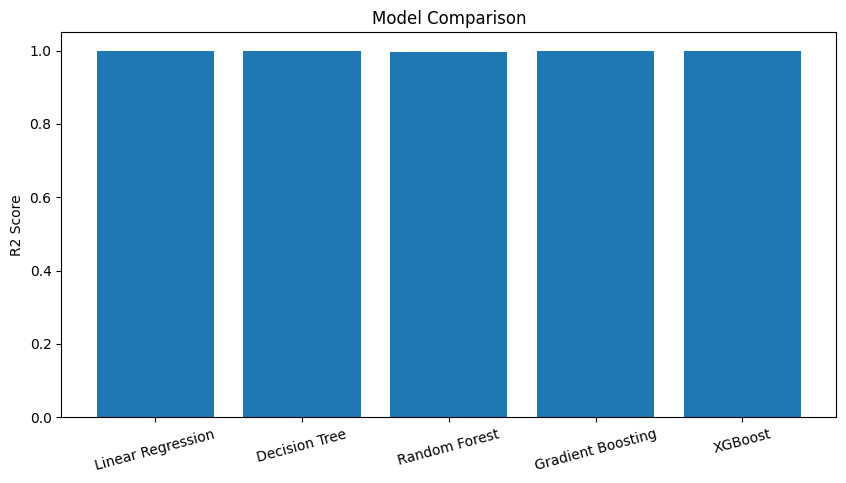

In [27]:
plt.figure(figsize=(10,5))

plt.bar(results.keys(), results.values())

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.xticks(rotation=15)

plt.show()

In [28]:
best_model = max(results, key=results.get)

print("Best Model:", best_model)

Best Model: Linear Regression


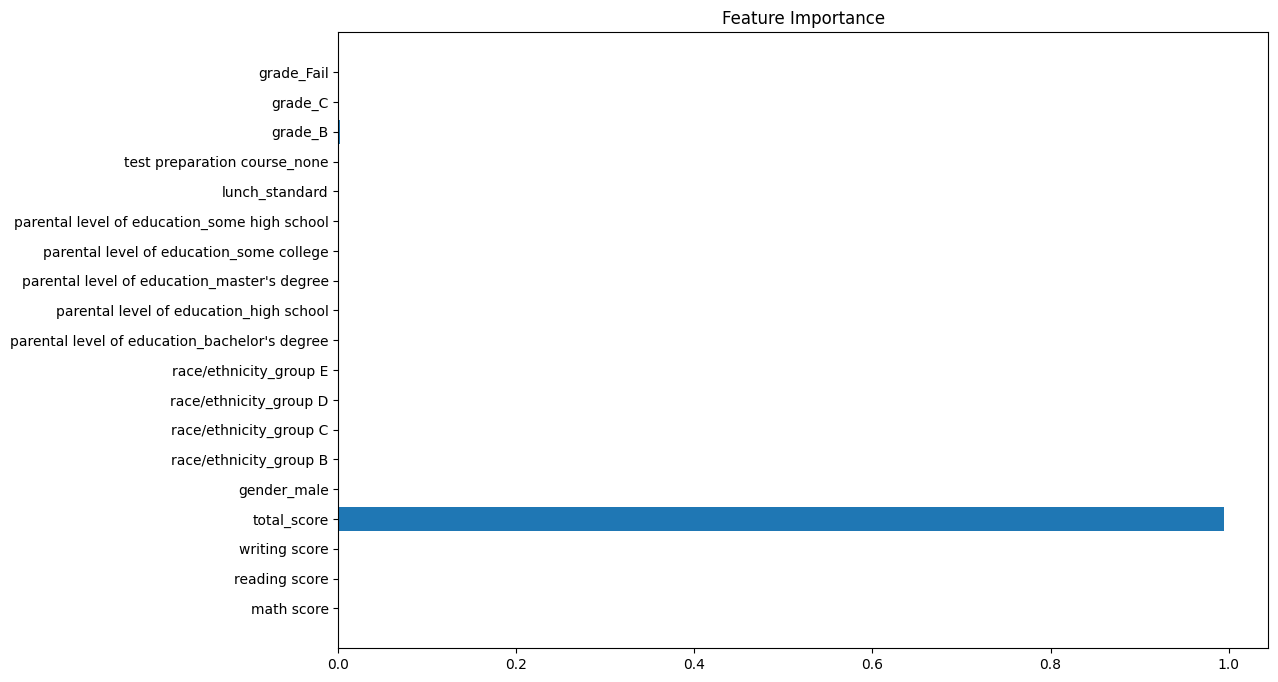

In [29]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(12,8))

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()

In [30]:
df['risk_level'] = np.where(
    df['average_score'] < 40,
    'High Risk',
    'Safe'
)

df[['average_score', 'risk_level']].head()

,average_score,risk_level
0,72.666667,Safe
1,82.333333,Safe
2,92.666667,Safe
3,49.333333,Safe
4,76.333333,Safe


In [31]:
sample = X_test.iloc[0:1]

prediction = rf.predict(sample)

print("Predicted Average Score:", prediction)

Predicted Average Score: [57.33666667]


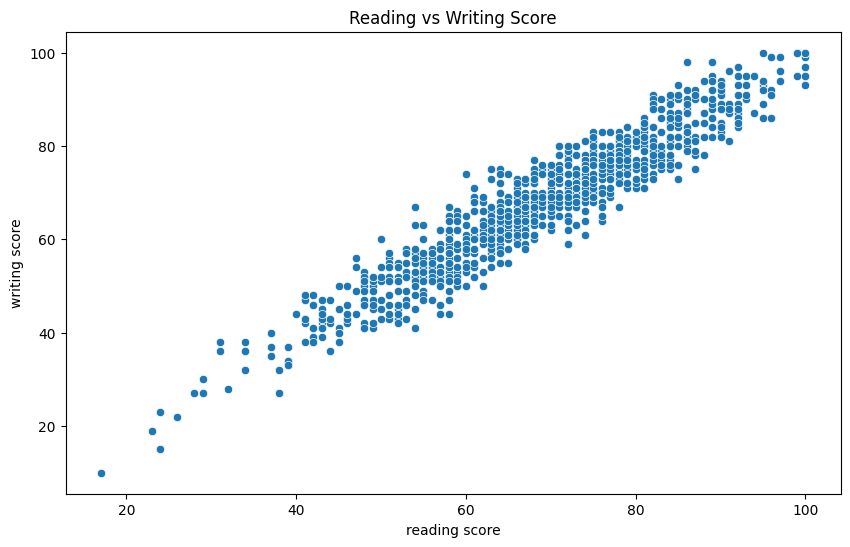

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='reading score',
    y='writing score',
    data=df
)

plt.title("Reading vs Writing Score")

plt.show()

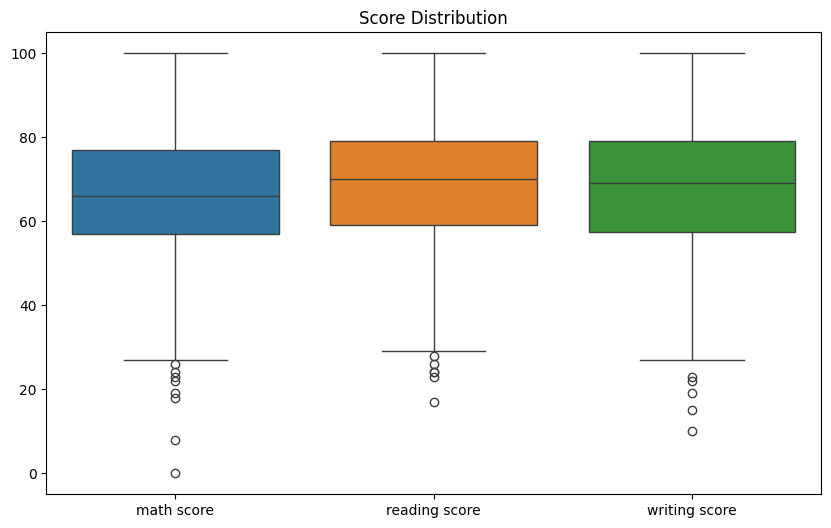

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df[['math score',
                     'reading score',
                     'writing score']])

plt.title("Score Distribution")

plt.show()

In [35]:
top_students = df.sort_values(
    by='average_score',
    ascending=False
).head(10)

top_students[['average_score']]

,average_score
962,100.000000
916,100.000000
458,100.000000
114,99.666667
712,99.000000
179,99.000000
165,98.666667
625,98.666667
903,97.666667
685,97.666667


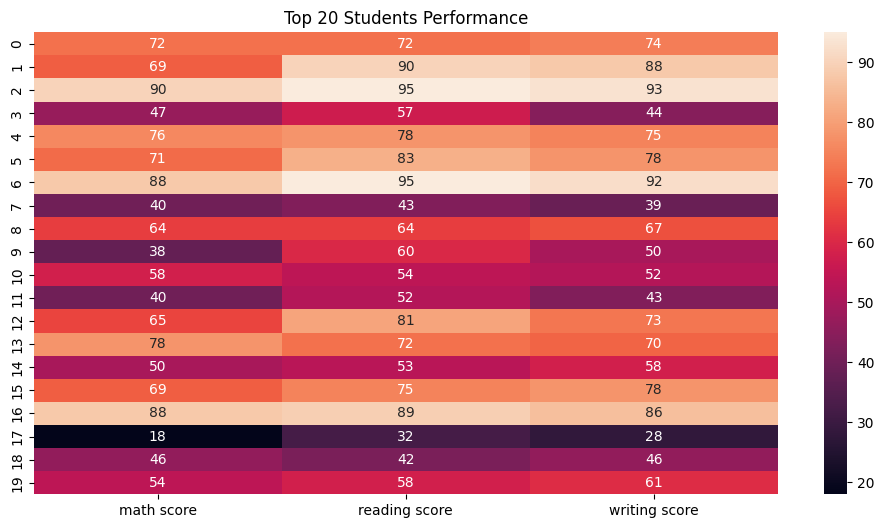

In [36]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df[['math score',
        'reading score',
        'writing score']].head(20),

    annot=True
)

plt.title("Top 20 Students Performance")

plt.show()

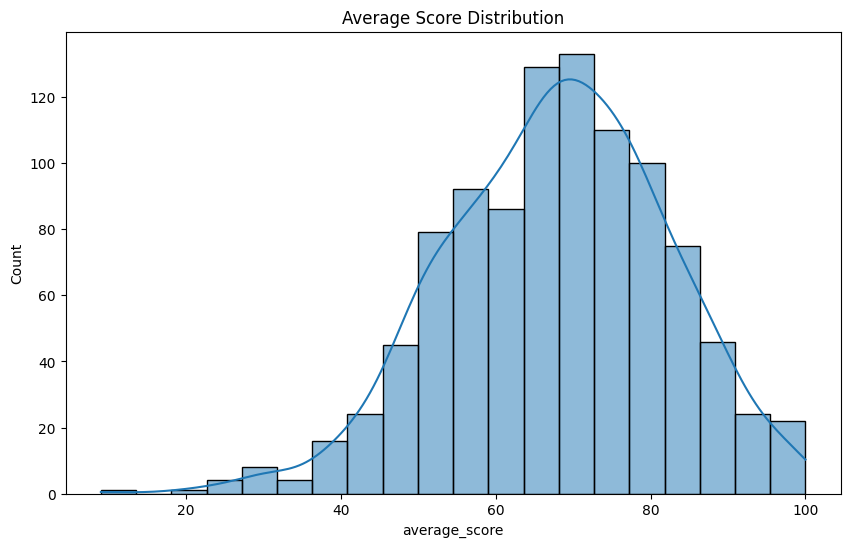

In [37]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['average_score'],
    kde=True,
    bins=20
)

plt.title("Average Score Distribution")

plt.show()

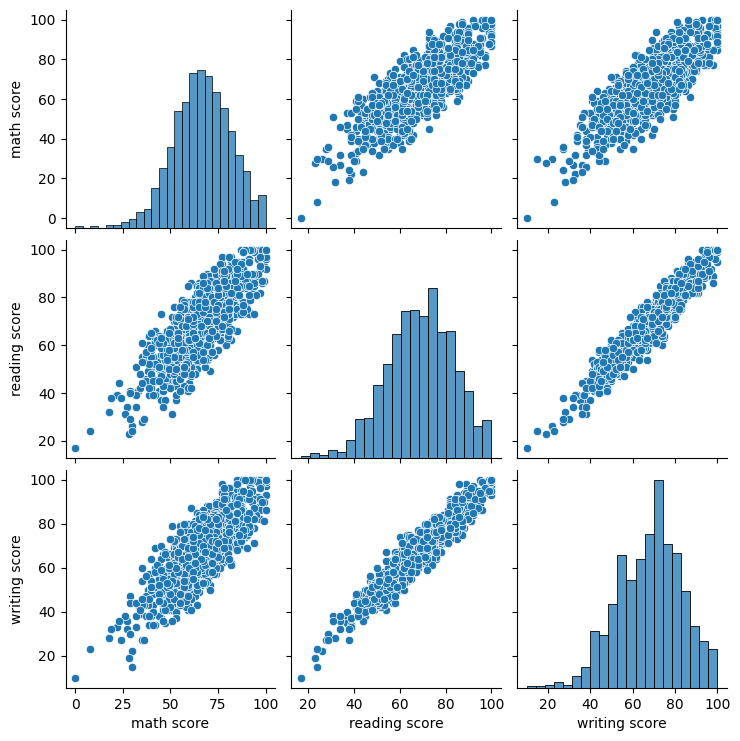

In [38]:
sns.pairplot(df[[
    'math score',
    'reading score',
    'writing score'
]])

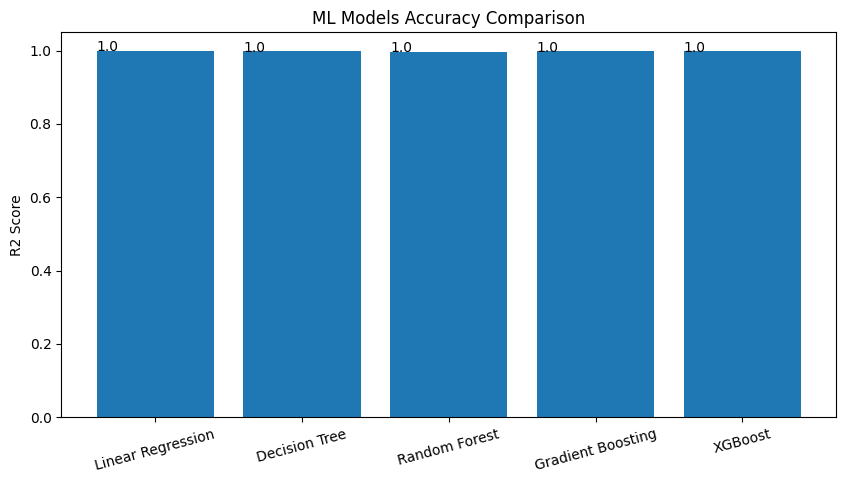

In [39]:
model_names = list(results.keys())

scores = list(results.values())

plt.figure(figsize=(10,5))

bars = plt.bar(model_names, scores)

plt.title("ML Models Accuracy Comparison")

plt.ylabel("R2 Score")

plt.xticks(rotation=15)

for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x(),
        yval,
        round(yval,2)
    )

plt.show()

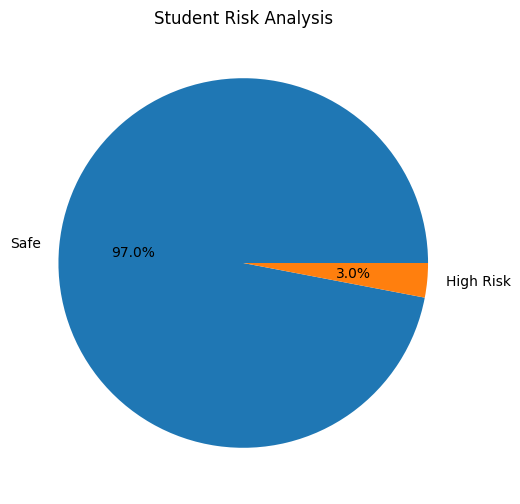

In [40]:
risk_counts = df['risk_level'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%'
)

plt.title("Student Risk Analysis")

plt.show()

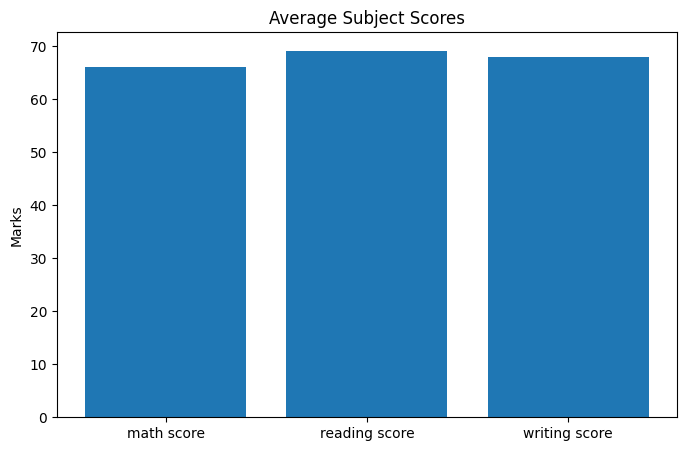

In [41]:
subjects = ['math score',
            'reading score',
            'writing score']

means = [
    df['math score'].mean(),
    df['reading score'].mean(),
    df['writing score'].mean()
]

plt.figure(figsize=(8,5))

plt.bar(subjects, means)

plt.title("Average Subject Scores")

plt.ylabel("Marks")

plt.show()

In [43]:
from matplotlib import animation